# Quick Check: In-Memory Generators
Runs topology, spatial traffic, and plotting using the self-contained module.

In [ ]:
# If needed, install deps
# !pip install -q pandas shapely scipy matplotlib


In [2]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [3]:
%matplotlib inline
from maveric_partform_module.utils import topology_gen, spatial_traffic_load_gen, plot_gen
from pathlib import Path
import json
from IPython.display import display


## 1) Topology + Config

In [4]:
topo_df, cfg_df, dummy_df = topology_gen(num_sites=3, cells_per_site=3)
print('Topology:', topo_df.shape, 'Config:', cfg_df.shape, 'Dummy:', dummy_df.shape)
display(topo_df.head())
display(cfg_df.head())


Topology: (9, 10) Config: (9, 3) Dummy: (0, 0)


,ecgi,site_id,cell_name,enodeb_id,cell_az_deg,tac,cell_lat,cell_lon,cell_id,cell_carrier_freq_mhz
0,1001,Site1,Site1_Cell1,1,0,1,40.737584,-74.043229,cell_1_0,2100
1,1001,Site1,Site1_Cell2,1,120,1,40.737584,-74.043229,cell_1_1,2100
2,1001,Site1,Site1_Cell3,1,240,1,40.737584,-74.043229,cell_1_2,2100
3,1004,Site2,Site2_Cell1,2,0,1,40.746612,-74.033135,cell_2_0,2100
4,1004,Site2,Site2_Cell2,2,120,1,40.746612,-74.033135,cell_2_1,2100


,cell_id,cell_el_deg,cell_carrier_freq_mhz
0,cell_1_0,12.0,2100
1,cell_1_1,12.0,2100
2,cell_1_2,12.0,2100
3,cell_2_0,12.0,2100
4,cell_2_1,12.0,2100


## 2) Spatial Traffic (per-day DataFrames)

In [7]:
# Use local JSON defaults (bundled in this folder)
num_ues = 50
days = 1
day_frames = spatial_traffic_load_gen(topology_df=topo_df, days=days, num_ues_per_tick=num_ues)
print('Days generated:', len(day_frames))
d0 = day_frames[0]
print('Day 0 rows:', len(d0), 'Columns:', list(d0.columns))
# Validate counts vs local time_params
try:
    with open((Path().resolve().parent / 'time_params.json'), 'r') as f:
        tp = json.load(f)
    expected = tp['total_ticks'] * num_ues
except FileNotFoundError:
    print("Warning: time_params.json not found. Using fallback value for total_ticks=24.")
    # Fallback: infer total_ticks from d0 if possible
    if 'tick' in d0.columns:
        total_ticks = d0['tick'].nunique()
    else:
        total_ticks = 24  # default fallback
    expected = total_ticks * num_ues

print('Expected rows:', expected, 'OK:', expected == len(d0))
display(d0.head())


Days generated: 1
Day 0 rows: 1200 Columns: ['ue_id', 'lon', 'lat', 'tick', 'space_type', 'day']
Expected rows: 1200 OK: True


,ue_id,lon,lat,tick,space_type,day
0,0,-73.983026,40.733688,0,dense,0
1,1,-74.042643,40.739380,0,dense,0
2,2,-74.040554,40.741280,0,dense,0
3,3,-74.038489,40.741398,0,dense,0
4,4,-73.959323,40.746568,0,dense,0


## 3) Plotting (in-memory Figures)

Figures generated: 2
Showing figure for (day, tick): (0, 0)


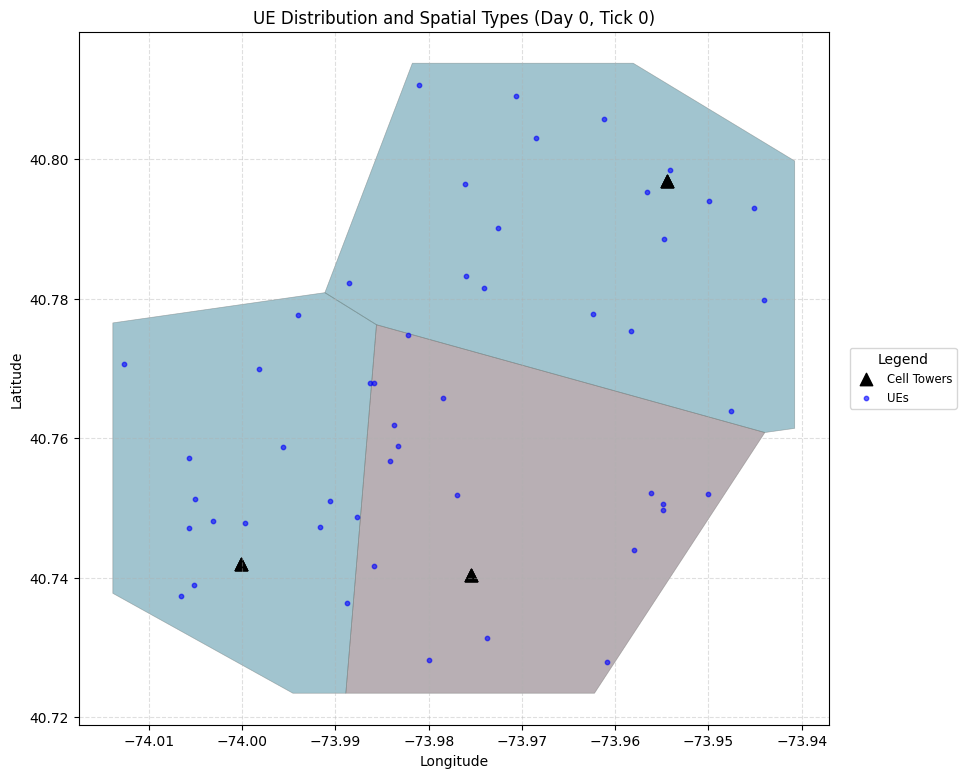

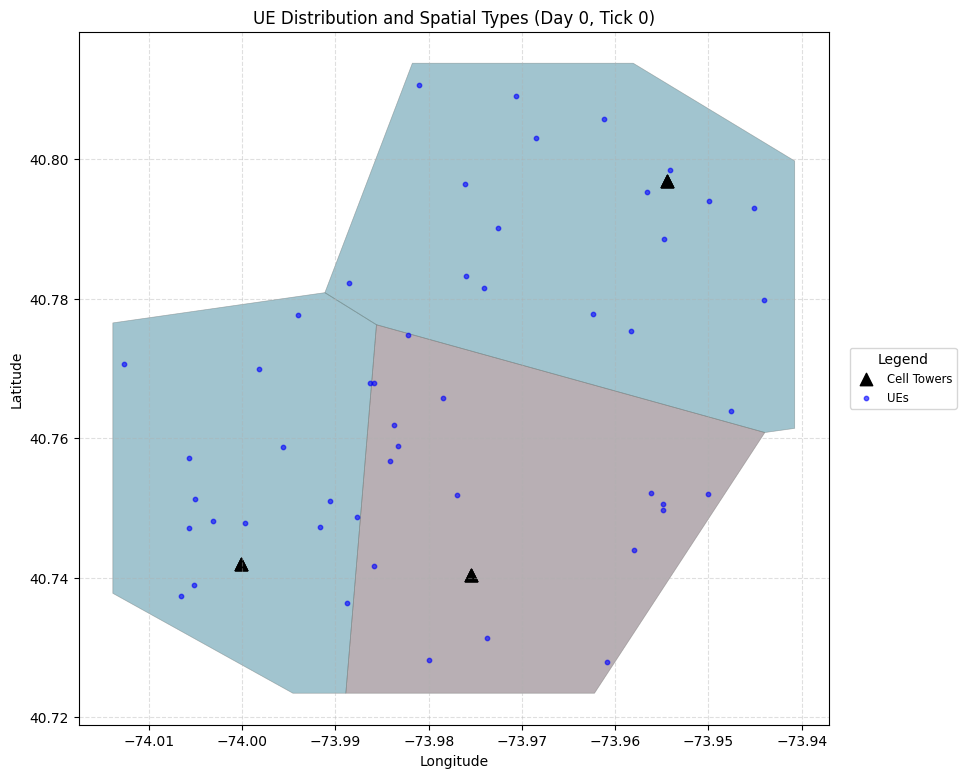

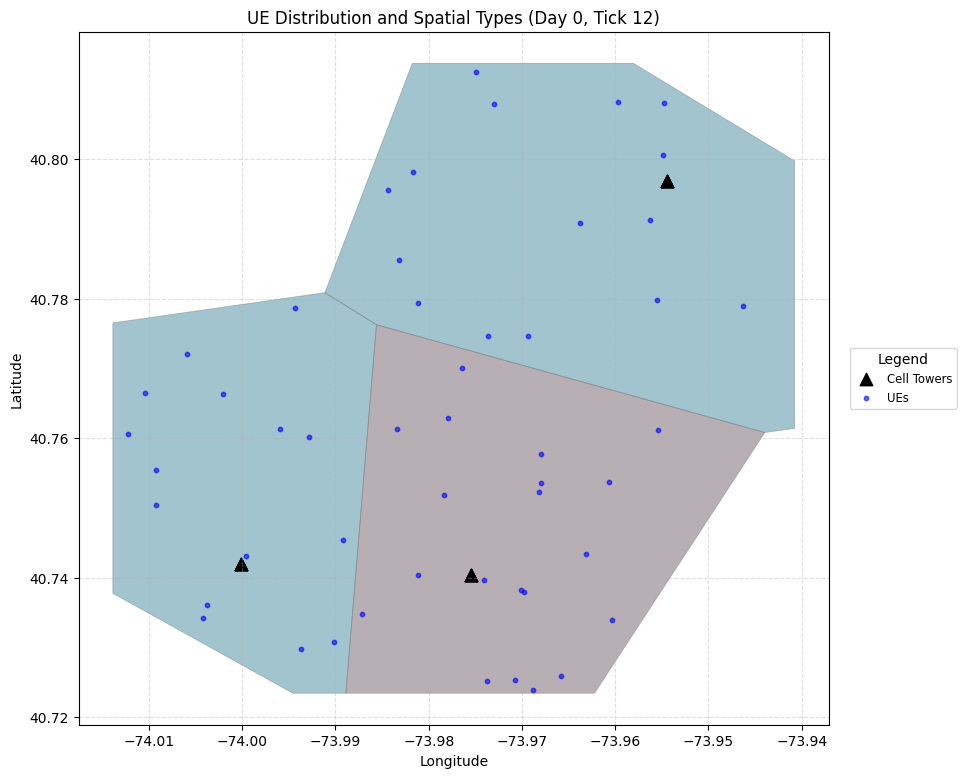

In [8]:
figs = plot_gen(days=1, num_sites=3, cells_per_site=3, num_ues_per_tick=num_ues, plot_max_ticks=2)
print('Figures generated:', len(figs))
# Display the first figure
if figs:
    key = sorted(figs.keys())[0]
    print('Showing figure for (day, tick):', key)
    display(figs[key])
